# Final Proyect Supervised Learning

## Caso 2. Clasificador del nivel de estrés

Tu departamento de recursos humanos quiere prevenir el estrés de los empleados dentro de la compañía. Para ello, lo principal es detectar el nivel de estrés de estos.

Debes desarrollar una solución que indique el nivel de estrés de un empleado que responde a un cuestionario. El nivel de estrés puede ser: no estresado (0-3), estresado(3-6) y extremadamente estresado(7-8).

1. Selecciona un algoritmo de los estudiados que pueda devolver el nivel de estrés del empleado (0-8). Justifica tu elección.
2. Determinar qué variables son las que más información aportan para predecir el nivel de estrés.
3. Clasificar los resultados del algoritmo en las 3 categorías de estrés indicadas (no estresado, estresado, extremadamente estresado) que piden en recursos humanos.
4. Reflexionar y responder a estas cuestiones:
    - ¿Crees que los datos usados son suficientes para predecir el nivel de estrés de un empleado? ¿Por qué?

### Loading and overview of the dataset

We use the dataset [Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset).

The dataset contains the following columns:
- Person ID: An identifier for each individual.
- Gender: The gender of the person (Male/Female).
- Age: The age of the person in years.
- Occupation: The occupation or profession of the person.
- Sleep Duration (hours): The number of hours the person sleeps per day.
- Quality of Sleep (scale: 1-10): A subjective rating of the quality of sleep, ranging from 1 to 10.
- Physical Activity Level (minutes/day): The number of minutes the person engages in physical activity daily.
- Stress Level (scale: 1-10): A subjective rating of the stress level experienced by the person, ranging from 1 to 10.
- BMI Category: The BMI category of the person (e.g., Underweight, Normal, Overweight).
- Blood Pressure (systolic/diastolic): The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure.
- Heart Rate (bpm): The resting heart rate of the person in beats per minute.
- Daily Steps: The number of steps the person takes per day.
- Sleep Disorder: The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea).

In [227]:
import pandas as pd

df = pd.read_csv('datasets/Sleep_health_and_lifestyle_dataset.csv')
print("Dataset size:", df.shape)
print(df.sample(10))

Dataset size: (374, 13)
     Person ID  Gender  Age   Occupation  Sleep Duration  Quality of Sleep  \
236        237    Male   44  Salesperson             6.4                 6   
210        211    Male   43     Engineer             7.7                 8   
302        303  Female   51        Nurse             7.1                 7   
312        313  Female   52     Engineer             8.4                 9   
341        342  Female   56       Doctor             8.2                 9   
119        120  Female   37   Accountant             7.2                 8   
48          49    Male   31       Doctor             7.7                 7   
90          91    Male   35     Engineer             7.3                 8   
258        259  Female   45      Teacher             6.6                 7   
339        340  Female   55        Nurse             8.1                 9   

     Physical Activity Level  Stress Level   BMI Category Blood Pressure  \
236                       45             

In [228]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None
        Person ID

In [229]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Sleep Health and Lifestyle Dataset Profiling Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 44114.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

After looking at the dataset, we can see that it contains a variety of features related to sleep health and lifestyle. The dataset has 374 rows and 13 columns, which is a reasonable size for training a machine learning model. There are some missing values and no duplicated.
Numeric variables:
- Person ID: We can drop this column as it does not provide any useful information for the model.
- Age (years)
- Sleep Duration (hours)
- Physical Activity Level (minutes/day)
- Quality of Sleep (scale: 1-10)
- Stress Level (scale: 1-10): This is the target variable we want to predict.
- Heart Rate (bpm)
- Daily Steps

Categorical variables:
- Gender: We can convert this column to numerical values using one-hot encoding. Dataset has 2 unique values and it is balanced.
- Occupation: We can convert this column to numerical values using one-hot encoding if needed. It has 11 unique values, which is not too high.
- BMI Category: We can convert this column to numerical values using one-hot encoding. It has 4 unique values, which is not too high.
- Blood Pressure (systolic/diastolic): We can split this column into two separate columns: systolic and diastolic so they can be used as numerical features.
- Sleep Disorder: We can convert this column to numerical values using one-hot encoding. It has 3 unique values, which is not too high. **NaN the lower category is wrongly classified as None**

> We need to normalize the numerical features to ensure that they are on the same scale. We can use Min-Max scaling or Standardization for this purpose.

> There are not duplicated rows in the dataset.

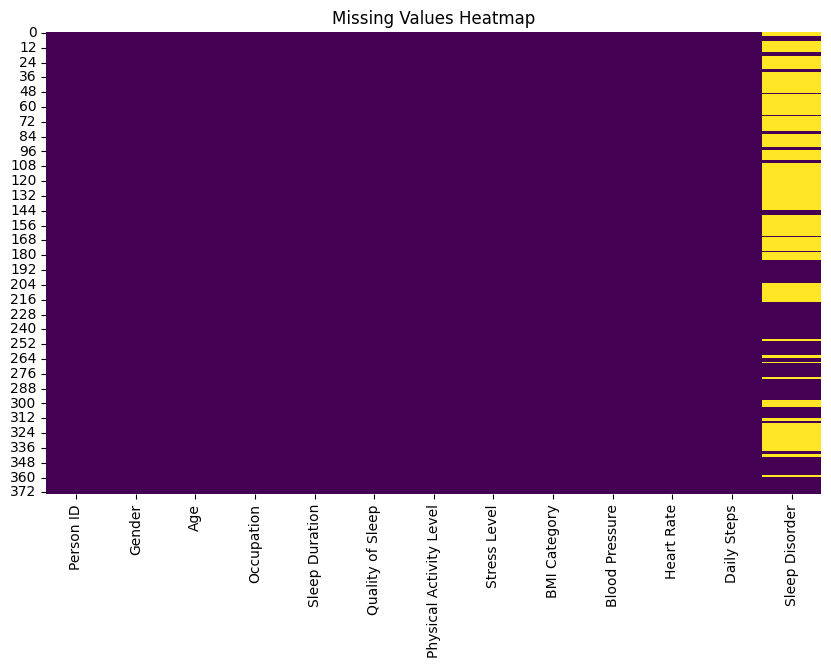

In [230]:
from matplotlib import pyplot as plt
import seaborn as sns

# interactive matplotlib plots
%matplotlib inline

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [231]:
df.drop(labels=['Person ID'], axis=1, inplace=True)

#### Encoding categorical variables and splitting blood pressure

In [232]:
# Blood Pressure as it's in reality two numerical features together
splitted_bp = df['Blood Pressure'].str.split('/', expand=True)
systolic = splitted_bp[0].astype(float)
diastolic = splitted_bp[1].astype(float)
df['Blood Pressure Systolic'] = systolic
df['Blood Pressure Diastolic'] = diastolic
df.drop(labels=['Blood Pressure'], axis=1, inplace=True)

In [233]:
# Not really a NaN, so we fill it with 'No Disorder'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')

Let's analyze categorical variables.

In [234]:
df['Gender'].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

In [235]:
df['Sleep Disorder'].value_counts()

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [236]:
df['BMI Category'].value_counts()

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

We have to rename Normal Weight to Normal for consistency. We could confirm if they are the same or if not dropping or renaming them.

In [237]:
df['BMI Category'] = df['BMI Category'].str.replace('Normal Weight', 'Normal')
df['BMI Category'].value_counts()

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

In [238]:
df['Occupation'].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [239]:
import plotly.express as px

fig=px.treemap(df,path=[px.Constant('Occupation'),'Sleep Disorder','Occupation'],
               color='Sleep Disorder',
              color_discrete_sequence=['#EBDEF0','#C39BD3','#4A235A'])


fig.update_layout(title='<b>The effect of job on sleep</b>..',
                 title_font={'size':20})


Nurse and Teacher occupations seems to have higher sleep related disorders.

In [240]:
import plotly.express as px

fig = px.treemap(
    df,
    path=[px.Constant('Occupation'), 'Occupation'],
    values='Sleep Duration',
    color='Sleep Duration',
    color_continuous_scale='Blues'
)

fig.update_layout(
    title='<b>Average Sleep Duration by Occupation</b>',
    title_font={'size': 20}
)

We can see how high responsability jobs like Manager, Sales, Software Developer have lower average sleep duration.

In [241]:
fig = px.treemap(
    df,
    path=[px.Constant('Occupation'), 'Occupation'],
    values='Quality of Sleep',
    color='Quality of Sleep',
    color_continuous_scale='Purples'
)

fig.update_layout(
    title='<b>Average Quality of Sleep by Occupation</b>',
    title_font={'size': 20}
)

We can see how high responsability jobs like Manager, Sales, Software Developer have lower average quality of sleep.

Let's encode  categorical variables now.

In [242]:
from sklearn.preprocessing import LabelEncoder

ordinal_features = ['BMI Category', 'Sleep Disorder']
nominal_features = ['Gender', 'Occupation']

for feature in ordinal_features:
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature])

df = pd.get_dummies(df, columns=nominal_features, drop_first=False)
print(df.sample(10))

     Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
154   39             7.2                 8                       60   
260   45             6.6                 7                       45   
156   39             7.2                 8                       60   
71    33             6.1                 6                       30   
206   43             7.7                 8                       90   
44    31             7.7                 7                       75   
338   54             8.5                 9                       30   
356   58             8.0                 9                       75   
322   53             8.4                 9                       30   
54    32             6.0                 6                       30   

     Stress Level  BMI Category  Heart Rate  Daily Steps  Sleep Disorder  \
154             5             0          68         8000               1   
260             4             2          65         6000          

Now that everything is numeric, we need to normalize the numerical features to ensure that they are on the same scale.

In [243]:
from sklearn.preprocessing import MinMaxScaler

numerical_columns = ['Age', 'Sleep Duration', 'Physical Activity Level',
                     'Quality of Sleep', 'Heart Rate', 'Daily Steps',
                     'Blood Pressure Systolic', 'Blood Pressure Diastolic']
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
print(df.sample(10))

         Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
260  0.56250        0.296296               0.6                 0.250000   
96   0.28125        0.518519               0.8                 0.500000   
5    0.03125        0.037037               0.0                 0.000000   
280  0.71875        0.074074               0.4                 1.000000   
33   0.12500        0.111111               0.4                 0.000000   
57   0.15625        0.074074               0.4                 0.000000   
68   0.18750        0.148148               0.4                 0.333333   
45   0.12500        0.740741               0.6                 0.750000   
276  0.68750        0.851852               1.0                 0.916667   
10   0.06250        0.111111               0.4                 0.000000   

     Stress Level  BMI Category  Heart Rate  Daily Steps  Sleep Disorder  \
260             4             2    0.000000     0.428571               0   
96              4     

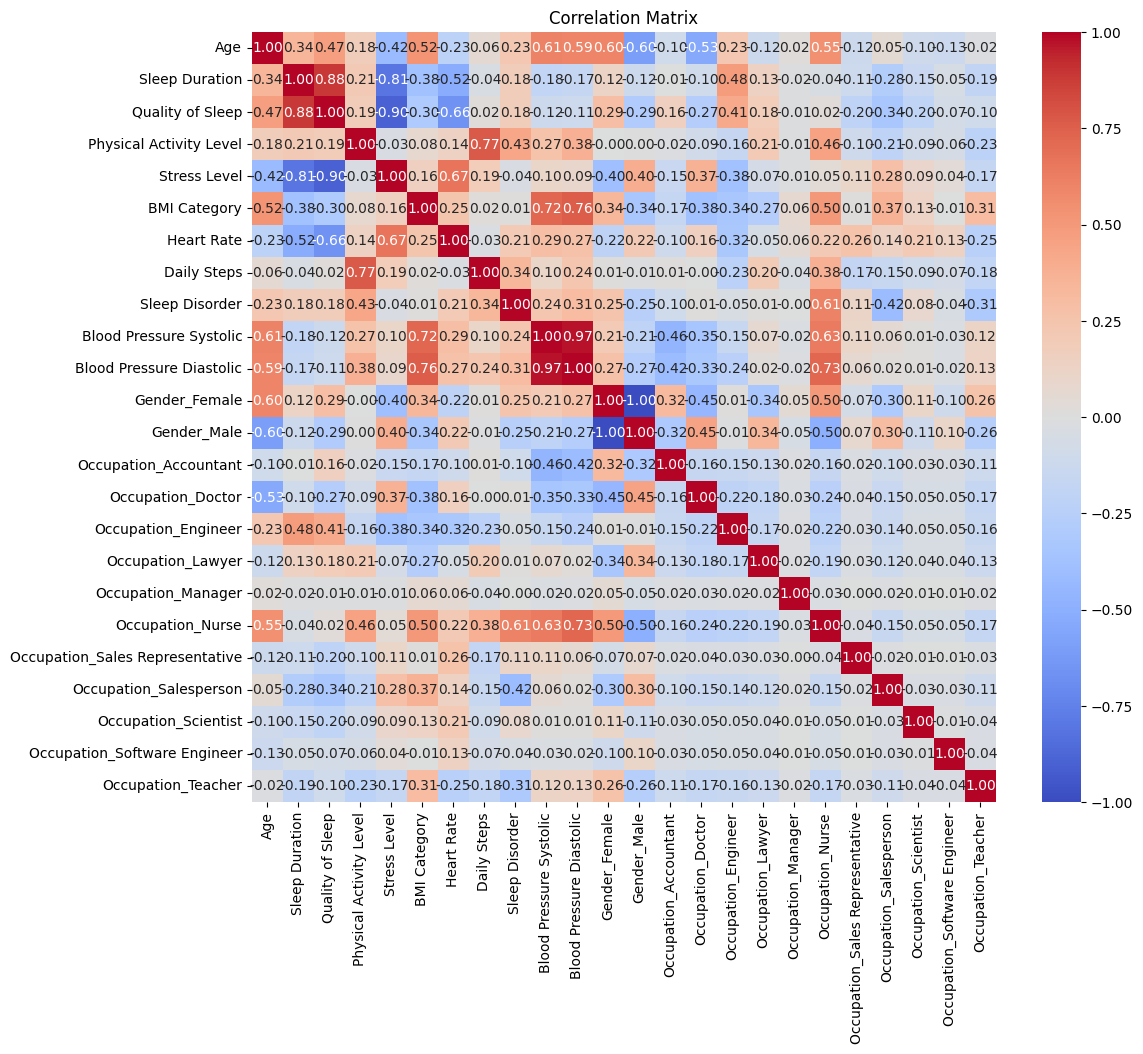

In [244]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- Stress Level seems correlated with Heart Rate, Male gender, Occupation Doctor and Occupation Salesperson.
- Sleep Disorder seems correlated with Physical Activity Level, Daily Steps, blood pressure, being Male and highly correlated with occupation Nurse.
- Sleep Duration is highly correlated with Quality of Sleep.
- BMI Category is correlated with Age and Blood Pressure.
- Physical Activity Level is highly correlated with Daily Steps.
- Female is correlated with occupation Nurse and Teacher.
- Male is correlated with occupation Doctor, Lawyer and Salesperson.

Finally we split the dataset into features and target variable and then into training and testing sets.

In [245]:
from sklearn.model_selection import train_test_split

X = df.drop('Stress Level', axis=1)
y = df['Stress Level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Model Selection and Training

Stress Level is a multiclass classification problem with three classes: no stressed (0-3), stressed (4-6) and extremely stressed (7-8). Or we can treat it as a regression problem predicting the stress level from 0 to 10.

#### Classification

Random Forest Classifier Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00        10
           5       1.00      0.93      0.96        14
           6       0.91      1.00      0.95        10
           7       1.00      1.00      1.00        12
           8       1.00      1.00      1.00        17

    accuracy                           0.99        75
   macro avg       0.98      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



Text(0.5, 1.0, 'Confusion Matrix for Random Forest Classifier')

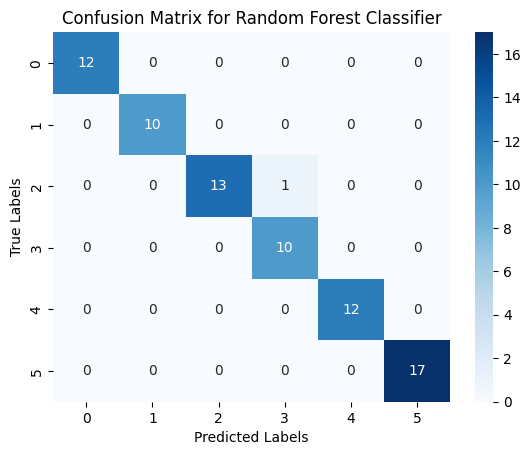

In [246]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest Classifier Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

ax = plt.subplot()
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix for Random Forest Classifier')

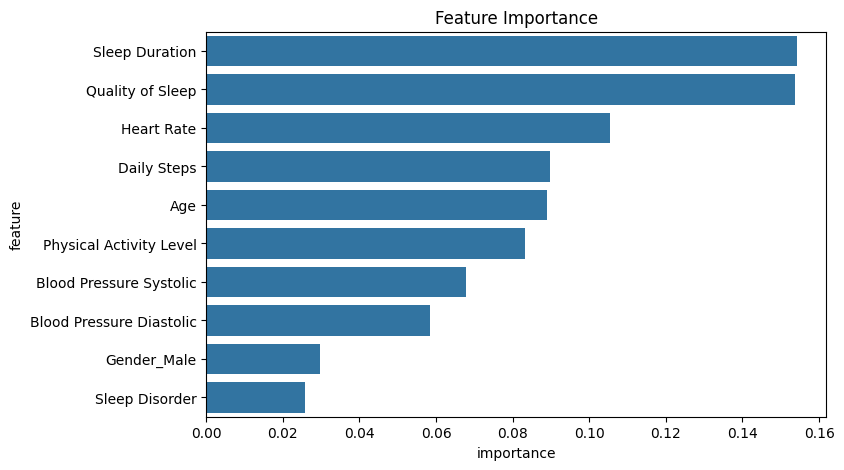

In [247]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Feature Importance")
plt.show()

RF has an accuracy of 0.99

#### Regression

In [248]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred_reg = lm.predict(X_test)

mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print(f'Linear Regression RMSE: {rmse:.2f}')
print(f'Linear Regression MAE: {mae:.2f}')
print(f'Linear Regression R²: {r2:.2f}')



Linear Regression RMSE: 0.37
Linear Regression MAE: 0.22
Linear Regression R²: 0.96


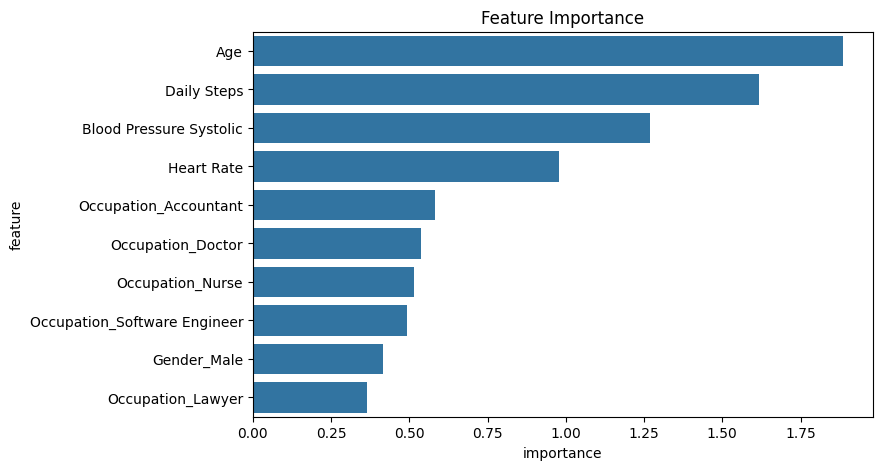

In [249]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lm.coef_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Feature Importance")
plt.show()

In [250]:

from sklearn.feature_selection import RFE

rfe = RFE(estimator=lm, n_features_to_select=10)
rfe.fit(X_train, y_train)
selected_features = X_train.columns[rfe.support_]
print("Top 10 selected features for Linear Regression:")
for feature in selected_features:
    print(feature)

rfe_pred = rfe.predict(X_test)
rfe_mse = mean_squared_error(y_test, rfe_pred)
rfe_rmse = np.sqrt(rfe_mse)
rfe_mae = mean_absolute_error(y_test, rfe_pred)
rfe_r2 = r2_score(y_test, rfe_pred)
print(f'RFE Linear Regression RMSE: {rfe_rmse:.2f}')
print(f'RFE Linear Regression MAE: {rfe_mae:.2f}')
print(f'RFE Linear Regression R²: {rfe_r2:.2f}')

Top 10 selected features for Linear Regression:
Age
Sleep Duration
Quality of Sleep
Heart Rate
Daily Steps
Blood Pressure Systolic
Blood Pressure Diastolic
Gender_Male
Occupation_Doctor
Occupation_Nurse
RFE Linear Regression RMSE: 0.36
RFE Linear Regression MAE: 0.26
RFE Linear Regression R²: 0.96


- Linear Regression has a R2 score of 0.96, MAE of 0.22 and RMSE of 0.37

- Linear Regression with RFE has a R2 score of 0.96, MAE of 0.26 and RMSE of 0.36 which is better than Linear Regression without feature selection. With a total of 10 features. Another option is to use 15 features where the R2 score is 0.94, MAE of 0.18 and RMSE of 0.22.

In [251]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)
print(f'Random Forest Regressor RMSE: {rf_rmse:.2f}')
print(f'Random Forest Regressor MAE: {rf_mae:.2f}')
print(f'Random Forest Regressor R²: {rf_r2:.2f}')

Random Forest Regressor RMSE: 0.18
Random Forest Regressor MAE: 0.05
Random Forest Regressor R²: 0.99


Random Forest Regressor has a R2 score of 0.99, MAE of 0.05 and RMSE of 0.18, which is much better than Linear Regression.

Now we will create a new model to classify the stress levels into three categories: no stressed (0-3), stressed (4-6) and extremely stressed (7-8).

In [252]:
df['Stress Level'] = df['Stress Level'].replace([0, 1, 2, 3], 'No Stressed')
df['Stress Level'] = df['Stress Level'].replace([4, 5, 6], 'Stressed')
df['Stress Level'] = df['Stress Level'].replace([7, 8], 'Extremely Stressed')

df['Stress Level'].value_counts()

Stress Level
Stressed              183
Extremely Stressed    120
No Stressed            71
Name: count, dtype: int64

In [253]:
df['Stress Level'] = le.fit_transform(df['Stress Level'])

X = df.drop('Stress Level', axis=1)
y = df['Stress Level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Random Forest Classifier Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      1.00      1.00        12
           2       1.00      0.97      0.99        34

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



[Text(0, 0.5, 'No Stressed'),
 Text(0, 1.5, 'Stressed'),
 Text(0, 2.5, 'Extremely Stressed')]

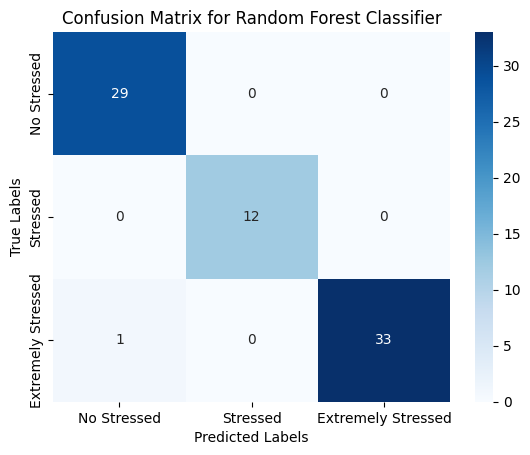

In [254]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest Classifier Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

ax = plt.subplot()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix for Random Forest Classifier')
ax.xaxis.set_ticklabels(['No Stressed', 'Stressed', 'Extremely Stressed'])
ax.yaxis.set_ticklabels(['No Stressed', 'Stressed', 'Extremely Stressed'])

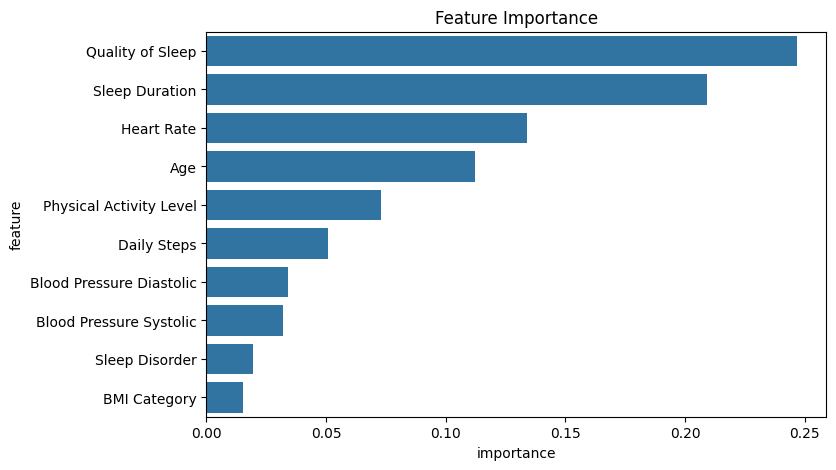

In [255]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Feature Importance")
plt.show()

RF has an accuracy of 0.99 with only 1 false positive and 0 false negatives.